In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_excel(r"c:\Users\LENOVO\Downloads\rollingsales_manhattan.xls", skiprows=4)

In [47]:
df.columns = df.columns.str.replace("\n", " ")
df.columns = df.columns.str.strip()
df.columns

Index(['BOROUGH', 'NEIGHBORHOOD', 'BUILDING CLASS CATEGORY',
       'TAX CLASS AT PRESENT', 'BLOCK', 'LOT', 'EASE-MENT',
       'BUILDING CLASS AT PRESENT', 'ADDRESS', 'APART MENT NUMBER', 'ZIP CODE',
       'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS',
       'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'YEAR BUILT',
       'TAX CLASS AT TIME OF SALE', 'BUILDING CLASS AT TIME OF SALE',
       'SALE PRICE', 'SALE DATE'],
      dtype='object')

In [50]:
# Convert SALE PRICE to numeric
df["SALE PRICE"] = pd.to_numeric(df["SALE PRICE"], errors="coerce")

# Remove fake sales
df = df[df['SALE PRICE'] != 0]

# Summary statistics
print(df["SALE PRICE"].describe())

count    1.980200e+04
mean     2.556609e+06
std      1.916295e+07
min      1.000000e+00
25%      3.676662e+05
50%      7.400000e+05
75%      1.627399e+06
max      1.307965e+09
Name: SALE PRICE, dtype: float64


NEIGHBORHOOD
MIDTOWN CBD                  2.384682e+07
SOUTHBRIDGE                  1.526396e+07
SOHO                         7.987728e+06
FASHION                      6.118131e+06
LITTLE ITALY                 4.767109e+06
FLATIRON                     4.747074e+06
JAVITS CENTER                4.583131e+06
HARLEM-WEST                  3.633810e+06
TRIBECA                      3.156453e+06
GRAMERCY                     3.103459e+06
Name: SALE PRICE, dtype: float64


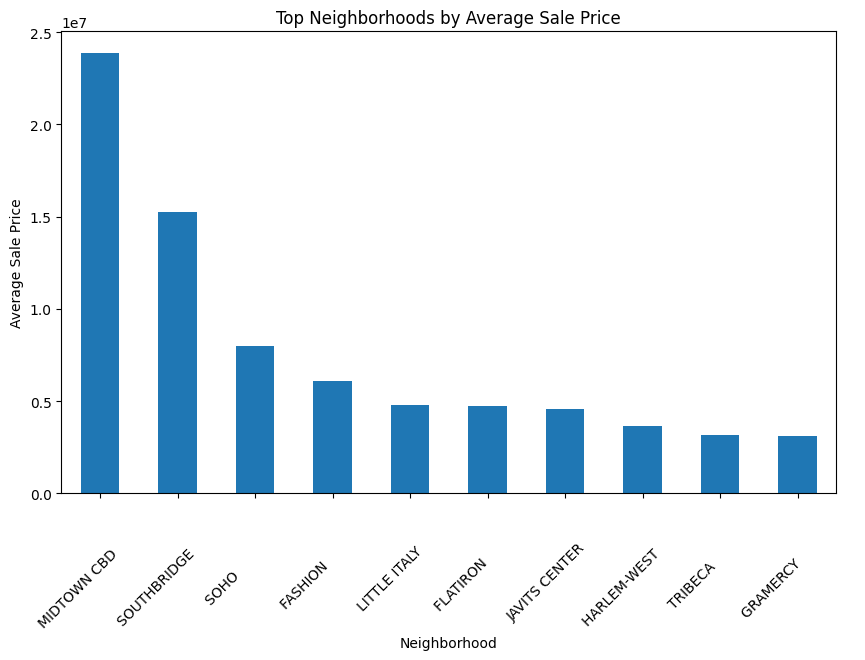

In [54]:
# Average price by neighborhood
avg_price = df.groupby("NEIGHBORHOOD")["SALE PRICE"].mean().sort_values(ascending=False)

print(avg_price.head(10))

# Bar chart
plt.figure(figsize=(10,6))
avg_price.head(10).plot(kind="bar")
plt.title("Top Neighborhoods by Average Sale Price")
plt.xlabel("Neighborhood")
plt.ylabel("Average Sale Price")
plt.xticks(rotation=45)
plt.show()

In [56]:
df['SALE DATE'] = pd.to_datetime(df['SALE DATE'], errors='coerce')

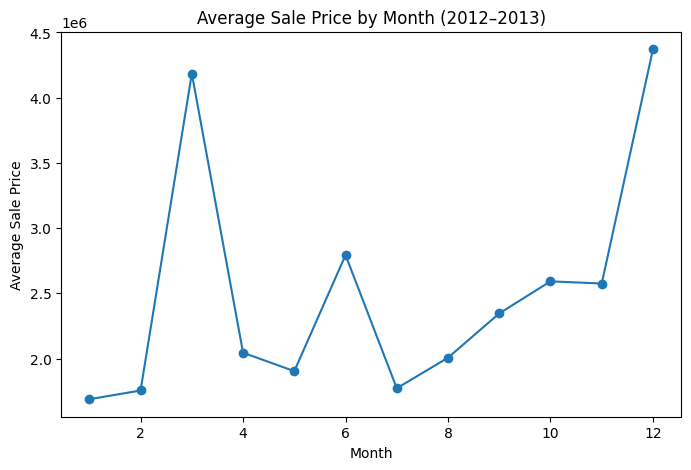

In [57]:
# Sales over time
sales_time = df.groupby(df['SALE DATE'].dt.month)['SALE PRICE'].mean()

plt.figure(figsize=(8,5))
sales_time.plot(marker='o')

plt.title("Average Sale Price by Month (2012–2013)")
plt.xlabel("Month")
plt.ylabel("Average Sale Price")

plt.show()